In [1]:
from git import Repo
import sys

# Get the root directory of the git repo
repo = Repo(search_parent_directories=True)
repo_root = repo.git.rev_parse("--show-toplevel")

# Add root to sys.path so imports work from anywhere
sys.path.append(repo_root)


%load_ext autoreload
%autoreload 2

In [13]:
import torch
from src.data.test_dataset import HybridDataset

In [19]:
dataset = HybridDataset(square_crop=True,roots=["/home/teampc/LVSM-VAE/data/re10k_subset/train"])

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader


def visualize_batch(batch, save_path=None):
    """
    Visualize a batch from the dataset.
    
    Args:
        batch: Dictionary containing 'image', 'camtoworld', 'K', 'index', 'scene_name'
        save_path: Optional path to save the visualization
    """
    images = batch['image']  # Shape: [batch, views, 3, H, W]
    c2ws = batch['camtoworld']  # Shape: [batch, views, 4, 4]
    intrinsics = batch['K']  # Shape: [batch, views, 4] (fx, fy, cx, cy)
    scene_names = batch['scene_name']
    
    batch_size = images.shape[0]
    num_views = images.shape[1]
    
    # Create figure
    fig = plt.figure(figsize=(20, 4 * batch_size))
    
    for b in range(batch_size):
        for v in range(num_views):
            ax = plt.subplot(batch_size, num_views, b * num_views + v + 1)
            
            # Get image and convert to displayable format
            img = images[b, v].cpu().numpy()  # [3, H, W]
            img = np.transpose(img, (1, 2, 0))  # [H, W, 3]
            img = np.clip(img, 0, 1)
            
            ax.imshow(img)
            ax.axis('off')
            
            # Add camera info as title
            cam_pos = c2ws[b, v, :3, 3].cpu().numpy()
            fx, fy, cx, cy = intrinsics[b, v].cpu().numpy()
            
            title = f"View {v}\n"
            title += f"Pos: [{cam_pos[0]:.2f}, {cam_pos[1]:.2f}, {cam_pos[2]:.2f}]\n"
            title += f"fx: {fx:.1f}, fy: {fy:.1f}"
            ax.set_title(title, fontsize=8)
        
        # Add scene name
        fig.text(0.02, 1 - (b + 0.5) / batch_size, 
                f"Scene: {scene_names[b]}", 
                fontsize=10, fontweight='bold',
                va='center', rotation=90)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {save_path}")
    else:
        plt.show()
    
    plt.close()


def visualize_camera_poses_3d(batch, save_path=None):
    """
    Visualize camera poses in 3D space.
    
    Args:
        batch: Dictionary containing camera data
        save_path: Optional path to save the visualization
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    c2ws = batch['camtoworld']  # Shape: [batch, views, 4, 4]
    scene_names = batch['scene_name']
    
    batch_size = c2ws.shape[0]
    
    fig = plt.figure(figsize=(15, 5 * batch_size))
    
    for b in range(batch_size):
        ax = fig.add_subplot(batch_size, 1, b + 1, projection='3d')
        
        # Extract camera positions and orientations
        positions = c2ws[b, :, :3, 3].cpu().numpy()  # [views, 3]
        
        # Plot camera positions
        ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], 
                  c='red', s=100, marker='o', label='Camera centers')
        
        # Plot camera orientations (forward direction)
        for i, c2w in enumerate(c2ws[b].cpu().numpy()):
            center = c2w[:3, 3]
            forward = c2w[:3, 2]  # Z-axis (forward)
            ax.quiver(center[0], center[1], center[2],
                     forward[0], forward[1], forward[2],
                     length=0.3, color='blue', arrow_length_ratio=0.3)
            
            # Label each camera
            ax.text(center[0], center[1], center[2], f'  {i}', fontsize=10)
        
        # Connect cameras in sequence
        ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 
               'g--', alpha=0.5, linewidth=1)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Camera Poses - Scene: {scene_names[b]}')
        ax.legend()
        
        # Set equal aspect ratio
        max_range = np.array([
            positions[:, 0].max() - positions[:, 0].min(),
            positions[:, 1].max() - positions[:, 1].min(),
            positions[:, 2].max() - positions[:, 2].min()
        ]).max() / 2.0
        
        mid_x = (positions[:, 0].max() + positions[:, 0].min()) * 0.5
        mid_y = (positions[:, 1].max() + positions[:, 1].min()) * 0.5
        mid_z = (positions[:, 2].max() + positions[:, 2].min()) * 0.5
        
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved 3D visualization to {save_path}")
    else:
        plt.show()
    
    plt.close()


def print_batch_info(batch):
    """Print detailed information about a batch."""
    print("\n" + "="*60)
    print("BATCH INFORMATION")
    print("="*60)
    
    images = batch['image']
    c2ws = batch['camtoworld']
    intrinsics = batch['K']
    indices = batch['index']
    scene_names = batch['scene_name']
    
    print(f"\nBatch size: {images.shape[0]}")
    print(f"Number of views: {images.shape[1]}")
    print(f"Image shape: {images.shape[2:]}")
    print(f"\nScene names: {scene_names}")
    
    for b in range(images.shape[0]):
        print(f"\n--- Scene {b}: {scene_names[b]} ---")
        print(f"Image indices: {indices[b, :, 0].tolist()}")
        print(f"Image value range: [{images[b].min():.3f}, {images[b].max():.3f}]")
        
        print("\nCamera positions:")
        for v in range(c2ws.shape[1]):
            pos = c2ws[b, v, :3, 3]
            print(f"  View {v}: [{pos[0]:7.3f}, {pos[1]:7.3f}, {pos[2]:7.3f}]")
        
        print("\nIntrinsics (fx, fy, cx, cy):")
        for v in range(intrinsics.shape[1]):
            K = intrinsics[b, v]
            print(f"  View {v}: [{K[0]:7.1f}, {K[1]:7.1f}, {K[2]:7.1f}, {K[3]:7.1f}]")


def test_dataset(dataset, num_samples=2, batch_size=2, save_dir="./vis_output"):
    """
    Test the dataset and create visualizations.
    
    Args:
        dataset: The HybridDataset instance
        num_samples: Number of samples to visualize
        batch_size: Batch size for DataLoader
        save_dir: Directory to save visualizations
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    # Create DataLoader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0,  # Set to 0 for easier debugging
        collate_fn=collate_fn
    )
    
    print(f"Testing dataset with {num_samples} samples...")
    
    for i, batch in enumerate(dataloader):
        if i >= num_samples:
            break
        
        print(f"\n{'='*60}")
        print(f"Sample {i+1}/{num_samples}")
        print(f"{'='*60}")
        
        # Print batch information
        print_batch_info(batch)
        
        # Visualize images
        img_path = os.path.join(save_dir, f"sample_{i:03d}_images.png")
        visualize_batch(batch, save_path=img_path)
        
        # Visualize camera poses
        pose_path = os.path.join(save_dir, f"sample_{i:03d}_poses.png")
        visualize_camera_poses_3d(batch, save_path=pose_path)
    
    print(f"\n{'='*60}")
    print(f"Testing complete! Visualizations saved to: {save_dir}")
    print(f"{'='*60}\n")


def collate_fn(batch):
    """Custom collate function to handle batching."""
    if len(batch) == 0:
        return None
    
    # Stack tensors
    return {
        'image': torch.stack([item['image'] for item in batch]),
        'camtoworld': torch.stack([item['camtoworld'] for item in batch]),
        'K': torch.stack([item['K'] for item in batch]),
        'index': torch.stack([item['index'] for item in batch]),
        'scene_name': [item['scene_name'] for item in batch]
    }


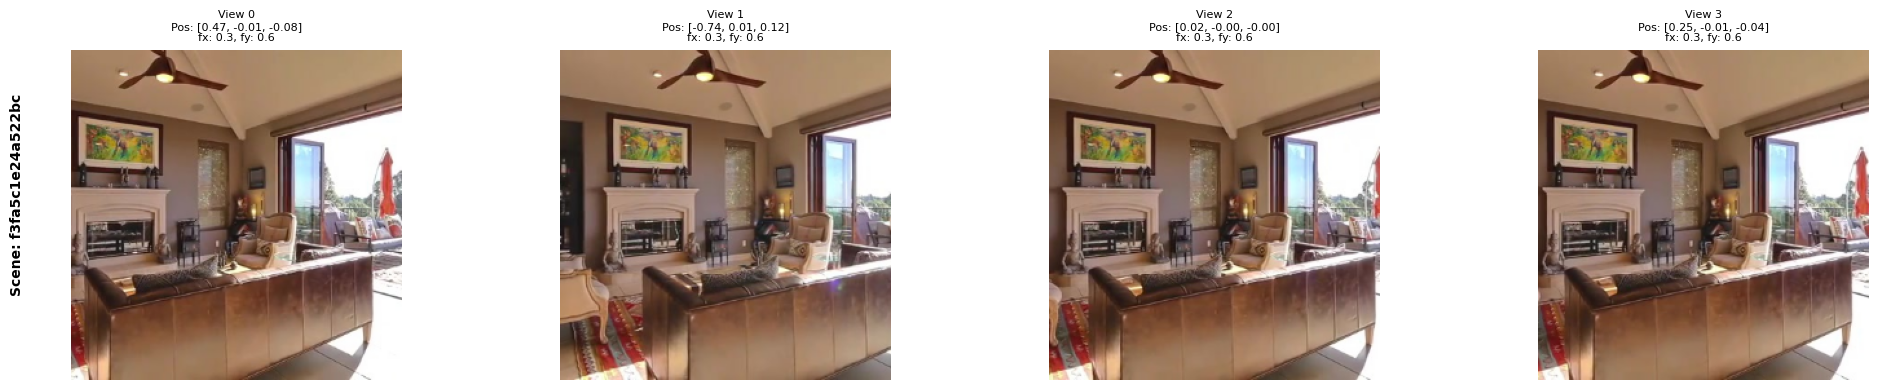

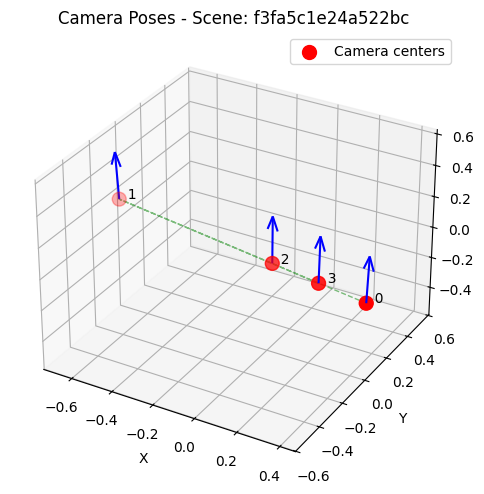


BATCH INFORMATION

Batch size: 1
Number of views: 4
Image shape: torch.Size([3, 256, 256])

Scene names: ['f3fa5c1e24a522bc']

--- Scene 0: f3fa5c1e24a522bc ---
Image indices: [12, 82, 38, 25]
Image value range: [0.000, 1.000]

Camera positions:
  View 0: [  0.471,  -0.008,  -0.075]
  View 1: [ -0.741,   0.014,   0.117]
  View 2: [  0.023,  -0.000,  -0.003]
  View 3: [  0.246,  -0.005,  -0.039]

Intrinsics (fx, fy, cx, cy):
  View 0: [    0.3,     0.6,   -95.7,     0.4]
  View 1: [    0.3,     0.6,   -95.7,     0.4]
  View 2: [    0.3,     0.6,   -95.7,     0.4]
  View 3: [    0.3,     0.6,   -95.7,     0.4]


In [62]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=1, collate_fn=collate_fn)
batch_new = next(iter(dataloader))

# Visualize
visualize_batch(batch_new)  # Shows images
visualize_camera_poses_3d(batch_new)  # Shows 3D camera positions
print_batch_info(batch_new) 

In [23]:
print(batch.keys())

dict_keys(['image', 'camtoworld', 'K', 'index', 'scene_name'])


In [39]:
from src.data.dataset import TrainDataset

In [ ]:
import glob
import os

TRAIN_FOLDER = "/home/teampc/LVSM-VAE/data/data_processed/realestate10k/train"
scenes = sorted(glob.glob("/home/teampc/LVSM-VAE/data/data_processed/realestate10k/train/*"))
train_dataset = TrainDataset(scenes, input_views=4, supervise_views=2)

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path


def visualize_lvsm_batch(batch, save_path=None, show=True):
    """
    Visualize a batch in LVSM format.
    
    Args:
        batch: Dictionary containing 'image', 'camtoworld', 'K', 'image_path' (optional)
        save_path: Optional path to save the visualization
        show: Whether to display the plot
    """
    images = batch['image']  # Shape: [batch, views, H, W, 3] or [batch, views, 3, H, W]
    c2ws = batch['camtoworld']  # Shape: [batch, views, 4, 4]
    K = batch['K']  # Shape: [batch, views, 3, 3]
    image_paths = batch.get('image_path', None)
    
    batch_size = images.shape[0]
    num_views = images.shape[1]
    
    # Determine image format and convert to [H, W, 3] if needed
    if images.shape[2] == 3 and len(images.shape) == 5:
        # Format: [batch, views, 3, H, W]
        images = images.permute(0, 1, 3, 4, 2)  # -> [batch, views, H, W, 3]
    
    # Create figure with more space for titles
    fig = plt.figure(figsize=(5 * num_views, 6 * batch_size))
    
    for b in range(batch_size):
        for v in range(num_views):
            ax = plt.subplot(batch_size, num_views, b * num_views + v + 1)
            
            # Get image and normalize to [0, 1] range
            img = images[b, v].cpu().numpy()
            if img.max() > 1.0:
                img = img / 255.0
            img = np.clip(img, 0, 1)
            
            ax.imshow(img)
            ax.axis('off')
            
            # Extract camera info
            cam_pos = c2ws[b, v, :3, 3].cpu().numpy()
            K_mat = K[b, v].cpu().numpy()
            fx, fy = K_mat[0, 0], K_mat[1, 1]
            cx, cy = K_mat[0, 2], K_mat[1, 2]
            
            # Build title
            title = f"View {v}\n"
            title += f"Pos: [{cam_pos[0]:.3f}, {cam_pos[1]:.3f}, {cam_pos[2]:.3f}]\n"
            title += f"K: fx={fx:.1f}, fy={fy:.1f}\n"
            title += f"   cx={cx:.1f}, cy={cy:.1f}"
            
            # Add image path if available
            if image_paths is not None:
                path = image_paths[b][v] if isinstance(image_paths[b], tuple) else image_paths[b]
                filename = Path(path).name if isinstance(path, str) else "N/A"
                title += f"\n{filename}"
            
            ax.set_title(title, fontsize=9, ha='center')
        
        # Add batch label
        fig.text(0.01, 1 - (b + 0.5) / batch_size, 
                f"Batch {b}", 
                fontsize=12, fontweight='bold',
                va='center', rotation=90)
    
    plt.tight_layout(rect=[0.02, 0, 1, 1])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved image visualization to {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close()


def visualize_lvsm_poses_3d(batch, save_path=None, show=True):
    """
    Visualize camera poses in 3D space for LVSM format batch.
    
    Args:
        batch: Dictionary containing camera data
        save_path: Optional path to save the visualization
        show: Whether to display the plot
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    c2ws = batch['camtoworld']  # Shape: [batch, views, 4, 4]
    image_paths = batch.get('image_path', None)
    
    batch_size = c2ws.shape[0]
    num_views = c2ws.shape[1]
    
    # Create figure
    fig = plt.figure(figsize=(10, 8 * batch_size))
    
    for b in range(batch_size):
        ax = fig.add_subplot(batch_size, 1, b + 1, projection='3d')
        
        # Extract camera positions and orientations
        positions = c2ws[b, :, :3, 3].cpu().numpy()  # [views, 3]
        
        # Plot camera positions
        ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], 
                  c='red', s=150, marker='o', label='Cameras', zorder=5)
        
        # Define colors for different camera axes
        colors = {'forward': 'blue', 'right': 'red', 'up': 'green'}
        
        # Plot camera orientations
        for i, c2w in enumerate(c2ws[b].cpu().numpy()):
            center = c2w[:3, 3]
            
            # Camera axes (OpenCV convention)
            right = c2w[:3, 0]     # X-axis (right)
            up = c2w[:3, 1]        # Y-axis (down in OpenCV, but we plot up)
            forward = c2w[:3, 2]   # Z-axis (forward)
            
            # Plot forward direction (most important)
            ax.quiver(center[0], center[1], center[2],
                     forward[0], forward[1], forward[2],
                     length=0.2, color=colors['forward'], 
                     arrow_length_ratio=0.3, linewidth=2, alpha=0.8)
            
            # Plot right direction
            ax.quiver(center[0], center[1], center[2],
                     right[0], right[1], right[2],
                     length=0.1, color=colors['right'], 
                     arrow_length_ratio=0.3, linewidth=1.5, alpha=0.6)
            
            # Label each camera
            ax.text(center[0], center[1], center[2] + 0.05, f'{i}', 
                   fontsize=10, fontweight='bold', zorder=10)
        
        # Connect cameras in sequence with dashed line
        ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 
               'gray', linestyle='--', alpha=0.4, linewidth=1.5)
        
        # Set labels and title
        ax.set_xlabel('X', fontsize=10, fontweight='bold')
        ax.set_ylabel('Y', fontsize=10, fontweight='bold')
        ax.set_zlabel('Z', fontsize=10, fontweight='bold')
        
        title = f'Camera Poses - Batch {b}'
        if image_paths is not None and b < len(image_paths):
            # Extract scene name from path
            path = image_paths[b][0] if isinstance(image_paths[b], tuple) else image_paths[b]
            if isinstance(path, str):
                scene_name = Path(path).parent.parent.name
                title += f'\nScene: {scene_name}'
        
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        
        # Create custom legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='red', marker='o', linestyle='', 
                   markersize=10, label='Camera'),
            Line2D([0], [0], color=colors['forward'], linewidth=2, 
                   label='Forward (Z)'),
            Line2D([0], [0], color=colors['right'], linewidth=1.5, 
                   label='Right (X)'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        
        # Set equal aspect ratio
        max_range = np.array([
            positions[:, 0].max() - positions[:, 0].min(),
            positions[:, 1].max() - positions[:, 1].min(),
            positions[:, 2].max() - positions[:, 2].min()
        ]).max() / 2.0
        
        mid_x = (positions[:, 0].max() + positions[:, 0].min()) * 0.5
        mid_y = (positions[:, 1].max() + positions[:, 1].min()) * 0.5
        mid_z = (positions[:, 2].max() + positions[:, 2].min()) * 0.5
        
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
        
        # Set better viewing angle
        ax.view_init(elev=20, azim=45)
        
        # Add grid
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved 3D pose visualization to {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close()


def print_lvsm_batch_info(batch):
    """Print detailed information about an LVSM format batch."""
    print("\n" + "="*70)
    print(" LVSM BATCH INFORMATION")
    print("="*70)
    
    images = batch['image']
    c2ws = batch['camtoworld']
    K = batch['K']
    image_paths = batch.get('image_path', None)
    scene_id = batch.get('scene', None)
    
    batch_size = images.shape[0]
    num_views = images.shape[1]
    
    # Determine image format
    if images.shape[2] == 3 and len(images.shape) == 5:
        img_shape = f"[{images.shape[3]}, {images.shape[4]}, 3]"
    else:
        img_shape = f"[{images.shape[2]}, {images.shape[3]}, 3]"
    
    print(f"\n📦 Batch size: {batch_size}")
    print(f"🎥 Number of views: {num_views}")
    print(f"🖼️  Image shape: {img_shape}")
    print(f"📊 Image value range: [{images.min():.2f}, {images.max():.2f}]")
    print(f"🆔 Scene IDs: {scene_id if scene_id is not None else 'N/A'}")
    
    for b in range(batch_size):
        print(f"\n{'─'*70}")
        print(f"🎬 BATCH {b}")
        print(f"{'─'*70}")
        
        # Scene information from paths
        if image_paths is not None and b < len(image_paths):
            print("\n📁 Image Paths:")
            for v in range(min(3, num_views)):  # Show first 3
                path = image_paths[b][v] if isinstance(image_paths[b], tuple) else image_paths[b]
                if isinstance(path, str):
                    print(f"   View {v}: .../{Path(path).parent.name}/{Path(path).name}")
            if num_views > 3:
                print(f"   ... and {num_views - 3} more views")
        
        # Camera positions
        print("\n📍 Camera Positions (X, Y, Z):")
        positions = c2ws[b, :, :3, 3].cpu().numpy()
        for v in range(num_views):
            pos = positions[v]
            print(f"   View {v}: [{pos[0]:8.4f}, {pos[1]:8.4f}, {pos[2]:8.4f}]")
        
        # Camera distances
        print("\n📏 Inter-camera Distances:")
        for v in range(num_views - 1):
            dist = np.linalg.norm(positions[v+1] - positions[v])
            print(f"   View {v} → {v+1}: {dist:.4f}")
        total_dist = np.linalg.norm(positions[-1] - positions[0])
        print(f"   Total (0 → {num_views-1}): {total_dist:.4f}")
        
        # Intrinsics
        print("\n🔍 Camera Intrinsics (K matrix):")
        K_mat = K[b, 0].cpu().numpy()  # Show first camera
        print(f"   View 0:")
        print(f"      fx={K_mat[0,0]:8.2f}, fy={K_mat[1,1]:8.2f}")
        print(f"      cx={K_mat[0,2]:8.2f}, cy={K_mat[1,2]:8.2f}")
        if num_views > 1:
            K_mat_last = K[b, -1].cpu().numpy()
            if not np.allclose(K_mat, K_mat_last):
                print(f"   View {num_views-1}:")
                print(f"      fx={K_mat_last[0,0]:8.2f}, fy={K_mat_last[1,1]:8.2f}")
                print(f"      cx={K_mat_last[0,2]:8.2f}, cy={K_mat_last[1,2]:8.2f}")
            else:
                print(f"   (All views have identical intrinsics)")
        
        # Pose statistics
        print("\n📈 Pose Statistics:")
        scene_center = positions.mean(axis=0)
        scene_extent = positions.max(axis=0) - positions.min(axis=0)
        print(f"   Scene Center: [{scene_center[0]:.4f}, {scene_center[1]:.4f}, {scene_center[2]:.4f}]")
        print(f"   Scene Extent: [{scene_extent[0]:.4f}, {scene_extent[1]:.4f}, {scene_extent[2]:.4f}]")
    
    print("\n" + "="*70 + "\n")

In [96]:
dataloader = DataLoader(train_dataset, batch_size=1)
batch = next(iter(dataloader))

# Visualize
# visualize_lvsm_batch(batch)  # Shows images


In [97]:
batch.keys()

dict_keys(['camtoworld', 'K', 'image', 'image_path'])

In [98]:
img = batch['image']  # Shape: [batch, views, H, W, 3] or [batch, views, 3, H, W]
img.shape

torch.Size([1, 6, 256, 256, 3])

In [93]:
img_new = batch_new['image']  # Shape: [batch, views, H, W, 3] or [batch, views, 3, H, W]
img_new.shape

torch.Size([1, 4, 3, 256, 256])